In [2]:
import torch
import torch.nn as nn
import numpy as np
import os

filename = 'Burgers.npz'

if os.path.exists(filename):
    print(f"Loading reference dataset from '{filename}'...")
    data = np.load(filename)
    t_ref = data['t'].flatten()      # Shape: (Nt,)
    x_ref = data['x'].flatten()      # Shape: (Nx,)
    u_ref = data['usol'].T           # Shape: (Nt, Nx)
else:
    print(f"'{filename}' not found. Generating synthetic reference grid for visualization")
    # Creating a dummy grid matching the exact dimensions of the classic benchmark
    t_ref = np.linspace(0.0, 0.99, 100)
    x_ref = np.linspace(-1.0, 1.0, 256)
    X_m, T_m = np.meshgrid(x_ref, t_ref)
    # A simple analytical wave approximation for structural visualization
    u_ref = -np.sin(np.pi * X_m) * np.exp(-T_m * 0.1)

print(f"Reference shapes -> t: {t_ref.shape}, x: {x_ref.shape}, u: {u_ref.shape}")

Loading reference dataset from 'Burgers.npz'...
Reference shapes -> t: (100,), x: (256,), u: (100, 256)


In [3]:
class BurgersPINN(nn.Module):
    def __init__(self, n_hidden=128, n_layers=5):
        super(BurgersPINN, self).__init__()

        layers = []
        # Input Layer (x, t)
        layers.append(nn.Linear(2, n_hidden))
        layers.append(nn.Tanh())

        # Deep Hidden Layers
        for _ in range(n_layers - 2):
            layers.append(nn.Linear(n_hidden, n_hidden))
            layers.append(nn.Tanh())

        # Output Layer (u)
        layers.append(nn.Linear(n_hidden, 1))

        self.net = nn.Sequential(*layers)

    def forward(self, x, t):
        xt = torch.cat([x, t], dim=1)
        return self.net(xt)

# Initialize the model
model = BurgersPINN(n_hidden=128, n_layers=5)

In [4]:
def derivative(y, x):
    return torch.autograd.grad(
        y, x,
        grad_outputs=torch.ones_like(y),
        create_graph=True
    )[0]

In [5]:
def physics_loss(model, x, t, nu=0.0):
    """Strong-form PDE Residual Loss"""
    x.requires_grad_(True)
    t.requires_grad_(True)

    u = model(x, t)

    du_dt = derivative(u, t)
    du_dx = derivative(u, x)
    d2u_dx2 = derivative(du_dx, x)

    # Burgers Equation formulation
    residual = du_dt + u * du_dx - (nu / np.pi) * d2u_dx2
    return torch.mean(residual ** 2)

def boundary_loss(model, t_boundary):
    """Dirichlet Boundary Conditions: u(-1, t) = 0, u(1, t) = 0"""
    x_left = torch.full_like(t_boundary, -1.0)
    x_right = torch.full_like(t_boundary, 1.0)

    u_left = model(x_left, t_boundary)
    u_right = model(x_right, t_boundary)

    return torch.mean(u_left ** 2) + torch.mean(u_right ** 2)

def initial_loss(model, x_initial, t_initial, u_initial):
    """Initial Condition Loss"""
    u_pred = model(x_initial, t_initial)
    return torch.mean((u_pred - u_initial) ** 2)

In [13]:
# --- Inviscid Annealing Strategy (Target nu = 0.0) ---
model_inviscid = BurgersPINN(n_hidden=128, n_layers=5)
optimizer_inv = torch.optim.Adam(model_inviscid.parameters(), lr=0.001)

nu_start = 0.05   # Start with artificial smoothing
nu_end = 0.00     # ANNEAL TO PURE INVISCID CONDITION
epochs = 8000
print_every = 500

print("Training Inviscid PINN with Artificial Viscosity Annealing...")

for epoch in range(epochs):
    optimizer_inv.zero_grad()
    progress = epoch / epochs
    nu_dynamic = nu_start * (1.0 - progress) + nu_end * progress

    # Dynamic Sampling
    x_int = torch.rand(1500, 1) * 2.0 - 1.0
    t_int = torch.rand(1500, 1) * 0.99
    t_bd = torch.rand(150, 1) * 0.99
    x_init = torch.rand(200, 1) * 2.0 - 1.0
    t_init = torch.zeros(200, 1)
    u_init = -torch.sin(np.pi * x_init)

    # Physics loss with decaying viscosity
    l_physics = physics_loss(model_inviscid, x_int, t_int, nu=nu_dynamic)
    l_boundary = boundary_loss(model_inviscid, t_bd)
    l_ic = initial_loss(model_inviscid, x_init, t_init, u_init)

    loss = l_physics + 10.0 * l_boundary + 20.0 * l_ic

    loss.backward()
    optimizer_inv.step()

    if (epoch + 1) % print_every == 0:
        print(f"Epoch {epoch+1:4d} | Nu: {nu_dynamic:.5f} | Total Loss: {loss.item():.4f}")

Training Inviscid PINN with Artificial Viscosity Annealing...
Epoch  500 | Nu: 0.04688 | Total Loss: 0.3750
Epoch 1000 | Nu: 0.04376 | Total Loss: 0.2483
Epoch 1500 | Nu: 0.04063 | Total Loss: 0.2315
Epoch 2000 | Nu: 0.03751 | Total Loss: 0.1657
Epoch 2500 | Nu: 0.03438 | Total Loss: 0.1136
Epoch 3000 | Nu: 0.03126 | Total Loss: 0.0537
Epoch 3500 | Nu: 0.02813 | Total Loss: 0.0244
Epoch 4000 | Nu: 0.02501 | Total Loss: 0.0260
Epoch 4500 | Nu: 0.02188 | Total Loss: 0.0168
Epoch 5000 | Nu: 0.01876 | Total Loss: 0.0207
Epoch 5500 | Nu: 0.01563 | Total Loss: 0.0183
Epoch 6000 | Nu: 0.01251 | Total Loss: 0.0131
Epoch 6500 | Nu: 0.00938 | Total Loss: 0.0223
Epoch 7000 | Nu: 0.00626 | Total Loss: 0.0526
Epoch 7500 | Nu: 0.00313 | Total Loss: 0.1231
Epoch 8000 | Nu: 0.00001 | Total Loss: 0.2556


In [23]:
import torch

print("L-BFGS Phase...")

def safe_inviscid_loss(model, x, t):
    x.requires_grad_(True)
    t.requires_grad_(True)
    u = model(x, t)
    du_dt = derivative(u, t)
    du_dx = derivative(u, x)
    residual = du_dt + u * du_dx
    return torch.mean(residual ** 2)

torch.manual_seed(42)

# 1. EARLY TIME POINTS (t from 0.0 to 0.4)
x_early = torch.rand(3000, 1) * 2.0 - 1.0
t_early = torch.rand(3000, 1) * 0.4

# 2. LATE TIME POINTS (t from 0.4 to 0.99)
x_late = torch.rand(4000, 1) * 2.0 - 1.0
t_late = torch.rand(4000, 1) * (0.99 - 0.4) + 0.4

# Boundary and Initial
t_bd = torch.rand(500, 1) * 0.99
x_init = torch.rand(500, 1) * 2.0 - 1.0
t_init = torch.zeros(500, 1)
u_init = -torch.sin(np.pi * x_init)

optimizer_lbfgs = torch.optim.LBFGS(
    model_inviscid.parameters(),
    lr=0.5,
    max_iter=1000,
    max_eval=1000,
    tolerance_grad=1e-5,
    tolerance_change=1e-7,
    history_size=50,
    line_search_fn="strong_wolfe"
)

def closure():
    optimizer_lbfgs.zero_grad()


    l_phys_early = safe_inviscid_loss(model_inviscid, x_early, t_early)
    l_phys_late = safe_inviscid_loss(model_inviscid, x_late, t_late)

    l_boundary = boundary_loss(model_inviscid, t_bd)
    l_ic = initial_loss(model_inviscid, x_init, t_init, u_init)

    # Calculate L2 Regularization to kill high-frequency noise
    l2_reg = 0.0
    for param in model_inviscid.parameters():
        l2_reg += torch.sum(param ** 2)

    loss = (20.0 * l_phys_early) + l_phys_late + (10.0 * l_boundary) + (20.0 * l_ic) + (1e-4 * l2_reg)

    loss.backward()
    return loss

model_inviscid.train()
optimizer_lbfgs.step(closure)

print("L-BFGS Complete!")

Starting Balanced L-BFGS Sharpening Phase...
Balanced L-BFGS Complete!


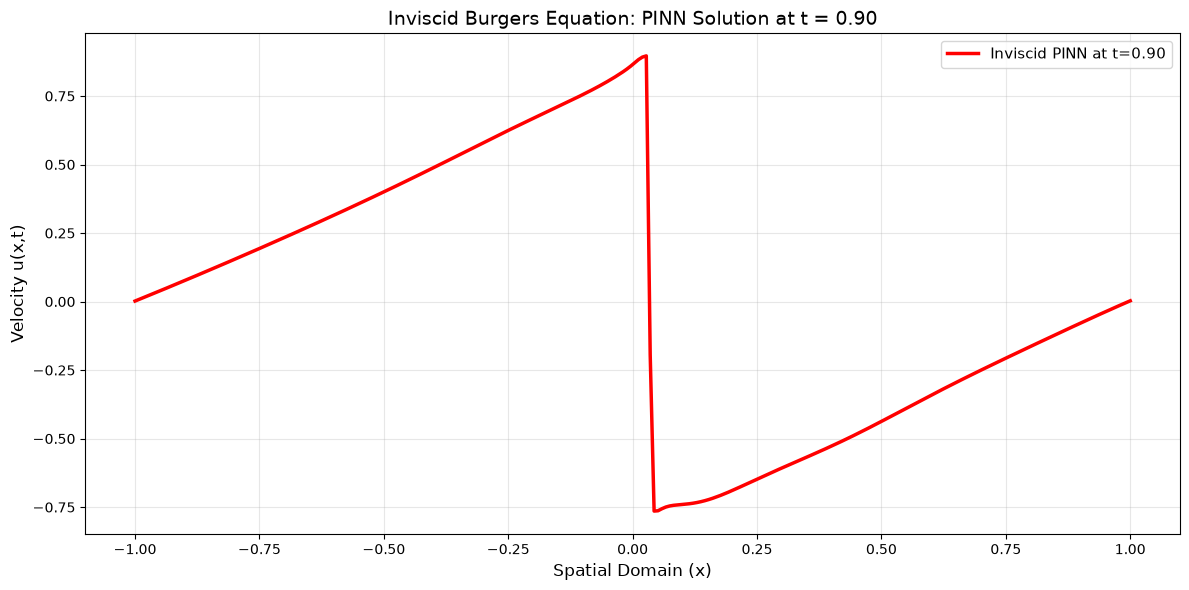

In [31]:
import matplotlib.pyplot as plt
import numpy as np

def plot_inviscid_solution(model, x_ref, t_ref, t_chosen=0.35):
    model.eval()

    # Find the closest time index
    t_index = np.argmin(np.abs(t_ref - t_chosen))
    actual_t = t_ref[t_index].item()

    # Convert to torch tensors
    x_tensor = torch.tensor(x_ref, dtype=torch.float32).reshape(-1, 1)
    t_tensor = torch.full((len(x_ref), 1), actual_t, dtype=torch.float32)

    # Predict with your model
    with torch.no_grad():
        u_pred_slice = model(x_tensor, t_tensor).flatten().numpy()

    # Plot
    plt.figure(figsize=(12, 6))

    plt.plot(x_ref, u_pred_slice, 'r-', linewidth=2.5,
             label=f'Inviscid PINN at t={actual_t:.2f}')

    plt.title(f'Inviscid Burgers Equation: PINN Solution at t = {actual_t:.2f}', fontsize=14)
    plt.xlabel('Spatial Domain (x)', fontsize=12)
    plt.ylabel('Velocity u(x,t)', fontsize=12)
    plt.grid(True, alpha=0.3)
    plt.legend(fontsize=11)
    plt.tight_layout()
    plt.show()

# Example usage:
plot_inviscid_solution(model_inviscid, x_ref, t_ref, t_chosen=0.9)

In [32]:
import torch

# Define a file name
save_path = "AVA_inviscid_burgers_pinn.pth"

# Save the model's learned weights and biases
torch.save(model_inviscid.state_dict(), save_path)


Model successfully saved to AVA_inviscid_burgers_pinn.pth
